<a href="https://colab.research.google.com/github/Uchihatt/My-Projects/blob/main/Using_SHAP_%2B_RFM_Aggregation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================
# Synthetic dataset generator
# Project 2: Customer Segmentation (Behavior + Value)
# Works in Google Colab / Jupyter
# =========================

import numpy as np
import pandas as pd
from datetime import datetime, timedelta

np.random.seed(42)

# ---- Config ----
N_CUSTOMERS = 3500
START_DATE = pd.Timestamp("2024-01-01")
END_DATE   = pd.Timestamp("2025-12-31")
CATEGORIES = ["Grocery", "Electronics", "Fashion", "Beauty", "Home", "Baby", "Pharmacy", "Sports"]
CHANNELS   = ["App", "Web", "Store"]
ACQ_CH     = ["Paid Social", "Paid Search", "Organic", "Referral", "Influencer", "CRM"]

# ---- Customer archetypes (hidden truth) ----
# We'll create 6 underlying behavior types to make clusters discoverable:
ARCHETYPES = [
    "HighValue_Loyal",      # high spend, frequent, low discount use
    "Deal_Seeker",          # frequent but discount-heavy
    "New_Explorer",         # new, browsing multiple categories, moderate spend
    "Seasonal_Spender",     # bursts of spend in certain months
    "OneTime_Buyer",        # 1-2 purchases then dormant
    "Return_Prone"          # decent spend but high returns
]

arch_probs = np.array([0.18, 0.22, 0.18, 0.14, 0.18, 0.10])
arch = np.random.choice(ARCHETYPES, size=N_CUSTOMERS, p=arch_probs)

# ---- Generate customers ----
signup_days = np.random.randint(0, (END_DATE - START_DATE).days + 1, size=N_CUSTOMERS)
signup_date = START_DATE + pd.to_timedelta(signup_days, unit="D")

customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(5)}" for i in range(N_CUSTOMERS)],
    "signup_date": signup_date,
    "region": np.random.choice(["Lahore", "Karachi", "Islamabad", "Faisalabad", "Multan"], size=N_CUSTOMERS, p=[0.30,0.30,0.15,0.15,0.10]),
    "acquisition_channel": np.random.choice(ACQ_CH, size=N_CUSTOMERS, p=[0.25,0.20,0.22,0.13,0.10,0.10]),
    "archetype_true": arch
})

# ---- Helper functions ----
def clip01(x):
    return np.minimum(1, np.maximum(0, x))

def random_date_between(start, end, n):
    delta = (end - start).days
    return start + pd.to_timedelta(np.random.randint(0, delta+1, size=n), unit="D")

# ---- Generate transactions per customer based on archetype ----
transactions = []
tid = 0

for idx, row in customers.iterrows():
    cid = row["customer_id"]
    sd = row["signup_date"]
    arche = row["archetype_true"]

    # Determine activity window
    start = sd
    end = END_DATE

    # Base purchase intensity + spend
    if arche == "HighValue_Loyal":
        n_orders = np.random.poisson(22) + 8
        base_aov = np.random.normal(8500, 1500)  # PKR-like
        disc_mu = 0.05
        return_prob = 0.05
        channel_pref = np.random.choice(["App","Web"], p=[0.7,0.3])
        cat_pref = np.random.choice(CATEGORIES, p=[0.18,0.18,0.10,0.10,0.16,0.08,0.10,0.10])

    elif arche == "Deal_Seeker":
        n_orders = np.random.poisson(18) + 5
        base_aov = np.random.normal(4500, 1200)
        disc_mu = 0.22
        return_prob = 0.07
        channel_pref = "App"
        cat_pref = np.random.choice(CATEGORIES, p=[0.25,0.08,0.22,0.12,0.10,0.08,0.10,0.05])

    elif arche == "New_Explorer":
        n_orders = np.random.poisson(10) + 2
        base_aov = np.random.normal(5200, 1400)
        disc_mu = 0.12
        return_prob = 0.06
        channel_pref = np.random.choice(CHANNELS, p=[0.45,0.45,0.10])
        cat_pref = None  # diversified

    elif arche == "Seasonal_Spender":
        n_orders = np.random.poisson(12) + 3
        base_aov = np.random.normal(7000, 1800)
        disc_mu = 0.10
        return_prob = 0.06
        channel_pref = np.random.choice(["Web","Store"], p=[0.65,0.35])
        cat_pref = np.random.choice(CATEGORIES, p=[0.12,0.20,0.10,0.08,0.22,0.06,0.10,0.12])

    elif arche == "OneTime_Buyer":
        n_orders = np.random.poisson(2) + 1
        base_aov = np.random.normal(4000, 1200)
        disc_mu = 0.14
        return_prob = 0.08
        channel_pref = np.random.choice(CHANNELS, p=[0.35,0.55,0.10])
        cat_pref = np.random.choice(CATEGORIES)

        # Many become inactive earlier
        end = sd + pd.to_timedelta(np.random.randint(30, 240), unit="D")
        if end > END_DATE:
            end = END_DATE

    elif arche == "Return_Prone":
        n_orders = np.random.poisson(14) + 4
        base_aov = np.random.normal(6000, 1600)
        disc_mu = 0.12
        return_prob = 0.22
        channel_pref = np.random.choice(CHANNELS, p=[0.30,0.55,0.15])
        cat_pref = np.random.choice(CATEGORIES, p=[0.10,0.18,0.18,0.10,0.16,0.06,0.12,0.10])

    # Generate purchase dates
    if end <= start:
        continue

    # For seasonal spender: concentrate orders in Nov/Dec + Eid-ish months (approx: Mar/Apr)
    if arche == "Seasonal_Spender":
        # Create a biased month distribution
        months = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
        probs = np.array([0.03,0.03,0.10,0.10,0.05,0.04,0.04,0.04,0.06,0.08,0.20,0.23])
        probs = probs / probs.sum()

        order_dates = []
        for _ in range(n_orders):
            m = np.random.choice(months, p=probs)
            # pick a date in that month across the time span years
            year = np.random.choice([2024, 2025], p=[0.48, 0.52])
            d0 = pd.Timestamp(f"{year}-{m:02d}-01")
            d1 = (d0 + pd.offsets.MonthEnd(0))
            # clamp into [start, end]
            d0 = max(d0, start)
            d1 = min(d1, end)
            if d1 < d0:
                continue
            order_dates.append(random_date_between(d0, d1, 1)[0])
        if len(order_dates) == 0:
            continue
        order_dates = pd.to_datetime(order_dates)

    else:
        order_dates = random_date_between(start, end, n_orders)

    order_dates = pd.to_datetime(order_dates).sort_values()

    for od in order_dates:
        tid += 1
        transaction_id = f"T{tid:07d}"

        # Category choice
        if arche == "New_Explorer":
            # diversified: pick with mild preference based on region/channel
            cat = np.random.choice(CATEGORIES, p=[0.16,0.14,0.14,0.12,0.16,0.08,0.12,0.08])
        else:
            # strong preference + occasional exploration
            if np.random.rand() < 0.70:
                cat = cat_pref
            else:
                cat = np.random.choice(CATEGORIES)

        # Channel choice
        if arche in ["HighValue_Loyal", "Deal_Seeker"]:
            channel = channel_pref if np.random.rand() < 0.75 else np.random.choice(CHANNELS)
        else:
            channel = channel_pref if np.random.rand() < 0.55 else np.random.choice(CHANNELS)

        # Discount %
        disc = clip01(np.random.normal(disc_mu, 0.07))
        # Basket items
        items = int(np.clip(np.random.normal(2.6, 1.2), 1, 10))

        # Order value (AOV) with category effect
        cat_multiplier = {
            "Grocery": 0.7, "Electronics": 1.8, "Fashion": 1.2, "Beauty": 1.0,
            "Home": 1.4, "Baby": 1.0, "Pharmacy": 0.8, "Sports": 1.1
        }[cat]
        raw_value = np.random.normal(base_aov, abs(base_aov)*0.18) * cat_multiplier
        raw_value = max(350, raw_value)
        order_value = raw_value * (1 - disc)

        returned = int(np.random.rand() < return_prob)

        transactions.append({
            "transaction_id": transaction_id,
            "customer_id": cid,
            "order_datetime": od + pd.to_timedelta(np.random.randint(0, 24), unit="h"),
            "order_value": round(order_value, 2),
            "items_count": items,
            "discount_pct": round(disc, 3),
            "channel": channel,
            "product_category": cat,
            "returned": returned
        })

transactions = pd.DataFrame(transactions).sort_values("order_datetime").reset_index(drop=True)

# Add a few realistic "refund adjustments" by reducing value if returned
transactions.loc[transactions["returned"]==1, "order_value"] *= np.random.uniform(0.0, 0.3, size=(transactions["returned"]==1).sum())

# ---- Save ----
customers.to_csv("customers.csv", index=False)
transactions.to_csv("transactions.csv", index=False)

print("Generated:")
print("customers.csv:", customers.shape)
print("transactions.csv:", transactions.shape)
customers.head(), transactions.head()


Generated:
customers.csv: (3500, 5)
transactions.csv: (56696, 9)


(  customer_id signup_date      region acquisition_channel    archetype_true
 0      C00000  2024-03-28      Multan             Organic       Deal_Seeker
 1      C00001  2024-09-12  Faisalabad            Referral      Return_Prone
 2      C00002  2025-05-25  Faisalabad         Paid Social     OneTime_Buyer
 3      C00003  2024-03-13   Islamabad         Paid Social  Seasonal_Spender
 4      C00004  2024-06-27      Lahore             Organic   HighValue_Loyal,
   transaction_id customer_id      order_datetime   order_value  items_count  \
 0       T0031642      C01937 2024-01-03 18:00:00    466.303442            2   
 1       T0051560      C03169 2024-01-03 20:00:00  11594.550000            2   
 2       T0026654      C01622 2024-01-07 11:00:00   4262.140000            3   
 3       T0004540      C00279 2024-01-07 16:00:00   1824.740000            1   
 4       T0004539      C00279 2024-01-07 19:00:00   2412.340000            2   
 
    discount_pct channel product_category  returned  
 

In [2]:
!pip -q install hdbscan shap


In [3]:
import pandas as pd

customers = pd.read_csv("customers.csv", parse_dates=["signup_date"])
transactions = pd.read_csv("transactions.csv", parse_dates=["order_datetime"])

# sanity
transactions = transactions[transactions["order_value"] >= 0]
transactions["month"] = transactions["order_datetime"].dt.to_period("M").dt.to_timestamp()
transactions.head()


,transaction_id,customer_id,order_datetime,order_value,items_count,discount_pct,channel,product_category,returned,month
0,T0031642,C01937,2024-01-03 18:00:00,466.303442,2,0.141,Store,Pharmacy,1,2024-01-01
1,T0051560,C03169,2024-01-03 20:00:00,11594.550000,2,0.139,Web,Electronics,0,2024-01-01
2,T0026654,C01622,2024-01-07 11:00:00,4262.140000,3,0.063,Web,Pharmacy,0,2024-01-01
3,T0004540,C00279,2024-01-07 16:00:00,1824.740000,1,0.264,App,Grocery,0,2024-01-01
4,T0004539,C00279,2024-01-07 19:00:00,2412.340000,2,0.210,App,Pharmacy,0,2024-01-01


In [4]:
import numpy as np

# Analysis date = last transaction date in dataset (typical RFM style)
analysis_date = transactions["order_datetime"].max() + pd.Timedelta(days=1)

# Base aggregates
agg = transactions.groupby("customer_id").agg(
    last_purchase=("order_datetime", "max"),
    frequency=("transaction_id", "count"),
    monetary=("order_value", "sum"),
    aov=("order_value", "mean"),
    avg_items=("items_count", "mean"),
    avg_discount=("discount_pct", "mean"),
    pct_returned=("returned", "mean"),
    unique_categories=("product_category", "nunique"),
    unique_channels=("channel", "nunique"),
)

agg["recency_days"] = (analysis_date - agg["last_purchase"]).dt.days

# Discounted orders share
disc_share = (transactions["discount_pct"] > 0.10).groupby(transactions["customer_id"]).mean()
agg["pct_discounted_orders"] = disc_share

# Channel shares
ch_pivot = pd.get_dummies(transactions["channel"]).groupby(transactions["customer_id"]).mean()
ch_pivot.columns = [f"share_{c.lower()}" for c in ch_pivot.columns]

# Category top
top_cat = (transactions.groupby(["customer_id", "product_category"])
           .size().reset_index(name="cnt")
           .sort_values(["customer_id", "cnt"], ascending=[True, False])
           .drop_duplicates("customer_id")[["customer_id", "product_category"]]
          ).set_index("customer_id")["product_category"]
agg["top_category"] = top_cat

# Tenure
feat = agg.merge(customers[["customer_id", "signup_date", "region", "acquisition_channel"]],
                 left_index=True, right_on="customer_id", how="left")
feat["tenure_days"] = (analysis_date - feat["signup_date"]).dt.days

# Merge channel shares
feat = feat.set_index("customer_id").join(ch_pivot, how="left").fillna(0).reset_index()

# Fill missing discount share
feat["pct_discounted_orders"] = feat["pct_discounted_orders"].fillna(0)

# Select numeric features for clustering
num_cols = [
    "recency_days","frequency","monetary","aov","avg_items","avg_discount",
    "pct_discounted_orders","pct_returned","unique_categories","unique_channels",
    "tenure_days","share_app","share_store","share_web"
]
feat[num_cols] = feat[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

feat.head()


,customer_id,last_purchase,frequency,monetary,aov,avg_items,avg_discount,pct_returned,unique_categories,unique_channels,recency_days,pct_discounted_orders,top_category,signup_date,region,acquisition_channel,tenure_days,share_app,share_store,share_web
0,C00000,2025-12-23 02:00:00,21,72073.857505,3432.088453,2.142857,0.186905,0.047619,6,3,9,0.904762,Pharmacy,2024-03-28,Multan,Organic,644,0.761905,0.095238,0.142857
1,C00001,2025-10-31 09:00:00,11,82447.733316,7495.248483,1.545455,0.130364,0.181818,3,2,62,0.818182,Electronics,2024-09-12,Faisalabad,Referral,476,0.000000,0.363636,0.636364
2,C00002,2025-10-22 16:00:00,2,4018.730000,2009.365000,3.000000,0.150500,0.000000,2,2,71,0.500000,Home,2025-05-25,Faisalabad,Paid Social,221,0.500000,0.000000,0.500000
3,C00003,2025-10-30 16:00:00,12,107851.804013,8987.650334,1.666667,0.076833,0.083333,2,3,63,0.416667,Sports,2024-03-13,Islamabad,Paid Social,659,0.083333,0.250000,0.666667
4,C00004,2025-12-09 09:00:00,25,256505.300000,10260.212000,1.920000,0.065800,0.000000,6,3,23,0.280000,Home,2024-06-27,Lahore,Organic,553,0.840000,0.120000,0.040000


In [5]:
from sklearn.preprocessing import StandardScaler

X = feat[num_cols].copy()

# log transform heavy-tailed money
X["monetary"] = np.log1p(X["monetary"])
X["aov"] = np.log1p(X["aov"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = {}
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

sil_scores
best_k = max(sil_scores, key=sil_scores.get)
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
feat["segment_kmeans"] = kmeans.fit_predict(X_scaled)

best_k, sil_scores[best_k], feat[["customer_id","segment_kmeans"]].head()


(6,
 np.float64(0.2212668228357477),
   customer_id  segment_kmeans
 0      C00000               5
 1      C00001               1
 2      C00002               2
 3      C00003               1
 4      C00004               4)

In [8]:
from sklearn.mixture import GaussianMixture

bics = {}
for k in range(3, 9):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bics[k] = gmm.bic(X_scaled)

best_g = min(bics, key=bics.get)
gmm = GaussianMixture(n_components=best_g, random_state=42)
feat["segment_gmm"] = gmm.fit_predict(X_scaled)

# soft probabilities (useful in marketing)
proba = gmm.predict_proba(X_scaled)
feat["gmm_confidence"] = proba.max(axis=1)

best_g, bics[best_g], feat[["customer_id","segment_gmm","gmm_confidence"]].head()


(8,
 np.float64(21620.417262265677),
   customer_id  segment_gmm  gmm_confidence
 0      C00000            2        0.999971
 1      C00001            1        0.999835
 2      C00002            3        1.000000
 3      C00003            1        0.999994
 4      C00004            6        1.000000)

In [9]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=120,
    min_samples=20
)
feat["segment_hdbscan"] = clusterer.fit_predict(X_scaled)  # -1 = noise/unclustered
feat["segment_hdbscan"].value_counts().head(10)


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


,count
segment_hdbscan,
-1,2293
0,572
1,342
2,150
3,131


In [11]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=120,
    min_samples=20
)
feat["segment_hdbscan"] = clusterer.fit_predict(X_scaled)  # -1 = noise/unclustered
feat["segment_hdbscan"].value_counts().head(10)


,count
segment_hdbscan,
-1,2293
0,572
1,342
2,150
3,131


In [15]:
SEG_COL = "segment_kmeans"

profile_mean = feat.groupby(SEG_COL)[num_cols].mean()
profile_median = feat.groupby(SEG_COL)[num_cols].median().add_suffix("_median")
sizes = feat.groupby(SEG_COL).size().rename("customers")

profile = (
    pd.concat([sizes, profile_mean, profile_median], axis=1)
      .sort_values("customers", ascending=False)
)

profile.head()


,customers,recency_days,frequency,monetary,aov,avg_items,avg_discount,pct_discounted_orders,pct_returned,unique_categories,...,avg_items_median,avg_discount_median,pct_discounted_orders_median,pct_returned_median,unique_categories_median,unique_channels_median,tenure_days_median,share_app_median,share_store_median,share_web_median
segment_kmeans,,,,,,,,,,,,,,,,,,,,,
1,910,24.432967,14.201099,77566.918085,5557.234696,2.199232,0.115021,0.568240,0.109403,5.113187,...,2.188988,0.115333,0.571429,0.083333,5.0,3.0,426.0,0.200000,0.153846,0.625000
5,828,17.398551,21.935990,79314.767953,3637.575337,2.205653,0.212337,0.936855,0.069601,5.118357,...,2.200000,0.217384,0.956522,0.058824,5.0,3.0,356.0,0.842105,0.080000,0.071429
4,645,13.026357,29.717829,262467.827933,8831.799389,2.210185,0.060152,0.236430,0.053954,5.751938,...,2.200000,0.059000,0.230769,0.047619,6.0,3.0,377.0,0.794118,0.080000,0.103448
2,408,73.068627,4.198529,19670.490638,4550.192743,2.321596,0.128237,0.636973,0.051925,2.031863,...,2.333333,0.122208,0.666667,0.000000,2.0,2.0,181.5,0.000000,0.000000,0.750000
3,356,29.123596,10.337079,62063.001594,6144.937217,2.119906,0.111641,0.554655,0.076454,3.643258,...,2.118056,0.110736,0.552778,0.000000,3.0,3.0,319.5,0.142857,0.700000,0.127717


In [16]:
def segment_story_cards(df, seg_col, num_cols):
    overall = df[num_cols].mean()
    cards = []

    for seg, sub in df.groupby(seg_col):
        if seg == -1:
            seg_name = "Unclustered / Mixed (Noise)"
        else:
            seg_name = f"Segment {seg}"

        means = sub[num_cols].mean()
        deltas = (means - overall).sort_values(ascending=False)

        # top distinguishing features (positive and negative)
        top_pos = deltas.head(4).index.tolist()
        top_neg = deltas.tail(4).index.tolist()

        # heuristic naming (simple but effective for portfolio)
        hv = means["monetary"] > overall["monetary"] and means["frequency"] > overall["frequency"]
        deal = means["avg_discount"] > overall["avg_discount"] or means["pct_discounted_orders"] > overall["pct_discounted_orders"]
        lapsing = means["recency_days"] > overall["recency_days"]
        returns = means["pct_returned"] > overall["pct_returned"]

        if seg == -1:
            title = "Mixed / Hard-to-Define Users"
            offer = "Generic onboarding + preference capture; move them into a clear path"
            msg = "Discover what you like—quick quiz + personalized picks"
        elif hv and not deal and not lapsing:
            title = "High-Value Loyalists"
            offer = "VIP tier, early access, loyalty multipliers, free express shipping"
            msg = "Exclusive benefits for our top customers—VIP access & priority service"
        elif deal and not hv:
            title = "Deal-Driven Value Shoppers"
            offer = "Bundle discounts, limited-time offers, threshold coupons (spend X get Y)"
            msg = "Best value drops—save more when you bundle"
        elif lapsing and hv:
            title = "Lapsing Big Spenders"
            offer = "Winback: personalized credit / free shipping / premium service reminder"
            msg = "We saved something you’ll love—come back for a tailored offer"
        elif returns:
            title = "Return-Prone Shoppers"
            offer = "Fit/compatibility guidance, size guides, reduce friction pre-purchase"
            msg = "Get it right the first time—guided picks + easy exchanges"
        else:
            title = "Steady Regulars / Mainstream"
            offer = "Cross-sell + subscribe/reorder prompts + mild incentives"
            msg = "Based on your routine—here are smart add-ons & reorders"

        # channel preference
        channel_cols = [c for c in num_cols if c.startswith("share_")]
        if channel_cols:
            ch = means[channel_cols].sort_values(ascending=False).index[0].replace("share_", "").upper()
        else:
            ch = "CRM"

        cards.append({
            "segment": seg,
            "persona_title": title,
            "who_they_are": f"Avg spend={means['monetary']:.1f}, freq={means['frequency']:.1f}, recency={means['recency_days']:.1f} days",
            "what_they_do": f"Top + drivers: {', '.join(top_pos)} | Biggest low: {', '.join(top_neg)}",
            "message_angle": msg,
            "offer_recommendation": offer,
            "best_channel": ch,
            "size_customers": len(sub)
        })

    return pd.DataFrame(cards).sort_values("size_customers", ascending=False)

story_cards = segment_story_cards(feat, SEG_COL, num_cols)
story_cards


,segment,persona_title,who_they_are,what_they_do,message_angle,offer_recommendation,best_channel,size_customers
1,1,Return-Prone Shoppers,"Avg spend=77566.9, freq=14.2, recency=24.4 days","Top + drivers: aov, tenure_days, unique_catego...",Get it right the first time—guided picks + eas...,"Fit/compatibility guidance, size guides, reduc...",WEB,910
5,5,Deal-Driven Value Shoppers,"Avg spend=79314.8, freq=21.9, recency=17.4 days","Top + drivers: frequency, unique_categories, s...",Best value drops—save more when you bundle,"Bundle discounts, limited-time offers, thresho...",APP,828
4,4,High-Value Loyalists,"Avg spend=262467.8, freq=29.7, recency=13.0 days","Top + drivers: monetary, aov, frequency, tenur...",Exclusive benefits for our top customers—VIP a...,"VIP tier, early access, loyalty multipliers, f...",APP,645
2,2,Deal-Driven Value Shoppers,"Avg spend=19670.5, freq=4.2, recency=73.1 days","Top + drivers: recency_days, share_web, avg_it...",Best value drops—save more when you bundle,"Bundle discounts, limited-time offers, thresho...",WEB,408
3,3,Steady Regulars / Mainstream,"Avg spend=62063.0, freq=10.3, recency=29.1 days","Top + drivers: aov, share_store, pct_returned,...",Based on your routine—here are smart add-ons &...,Cross-sell + subscribe/reorder prompts + mild ...,STORE,356
0,0,Deal-Driven Value Shoppers,"Avg spend=10199.0, freq=3.1, recency=450.4 days","Top + drivers: recency_days, tenure_days, pct_...",Best value drops—save more when you bundle,"Bundle discounts, limited-time offers, thresho...",WEB,341


In [17]:
story_cards.to_csv("segment_story_cards.csv", index=False)
print("Saved: segment_story_cards.csv")


Saved: segment_story_cards.csv


In [18]:
import pandas as pd
import numpy as np

# Build month-end snapshots
txn = transactions.copy()
txn["month"] = txn["order_datetime"].dt.to_period("M").dt.to_timestamp()

monthly = txn.groupby(["customer_id","month"]).agg(
    spend=("order_value","sum"),
    orders=("transaction_id","count"),
    aov=("order_value","mean"),
    avg_discount=("discount_pct","mean"),
    pct_returned=("returned","mean"),
    unique_categories=("product_category","nunique"),
    avg_items=("items_count","mean"),
).reset_index()

# channel shares per month
ch_month = (pd.get_dummies(txn["channel"])
            .groupby([txn["customer_id"], txn["month"]]).mean()
            .reset_index())
ch_month.columns = ["customer_id","month"] + [f"share_{c.lower()}" for c in ch_month.columns[2:]]

monthly = monthly.merge(ch_month, on=["customer_id","month"], how="left").fillna(0)

# recency at month-end
last_purchase_month = txn.groupby(["customer_id","month"])["order_datetime"].max().reset_index(name="last_purchase")
monthly = monthly.merge(last_purchase_month, on=["customer_id","month"], how="left")

monthly["month_end"] = (monthly["month"] + pd.offsets.MonthEnd(0))
monthly["recency_days"] = (monthly["month_end"] - monthly["last_purchase"]).dt.days

# tenure
monthly = monthly.merge(customers[["customer_id","signup_date"]], on="customer_id", how="left")
monthly["tenure_days"] = (monthly["month_end"] - monthly["signup_date"]).dt.days

monthly.head()


,customer_id,month,spend,orders,aov,avg_discount,pct_returned,unique_categories,avg_items,share_app,share_store,share_web,last_purchase,month_end,recency_days,signup_date,tenure_days
0,C00000,2024-04-01,9917.480000,2,4958.740000,0.1620,0.0,2,3.5,0.5,0.0,0.5,2024-04-30 06:00:00,2024-04-30,-1,2024-03-28,33
1,C00000,2024-05-01,23.717505,1,23.717505,0.3560,1.0,1,2.0,1.0,0.0,0.0,2024-05-17 02:00:00,2024-05-31,13,2024-03-28,64
2,C00000,2024-06-01,2951.630000,1,2951.630000,0.1560,0.0,1,2.0,0.0,1.0,0.0,2024-06-05 19:00:00,2024-06-30,24,2024-03-28,94
3,C00000,2024-07-01,6975.810000,2,3487.905000,0.2295,0.0,2,2.0,1.0,0.0,0.0,2024-07-13 03:00:00,2024-07-31,17,2024-03-28,125
4,C00000,2024-08-01,2743.590000,1,2743.590000,0.1300,0.0,1,3.0,1.0,0.0,0.0,2024-08-09 21:00:00,2024-08-31,21,2024-03-28,156


In [19]:
from sklearn.preprocessing import StandardScaler
import numpy as np

m_num_cols = [
    "recency_days","orders","spend","aov","avg_items","avg_discount",
    "pct_returned","unique_categories","tenure_days","share_app","share_store","share_web"
]

# prep X monthly
mX = monthly[m_num_cols].copy()
mX["spend"] = np.log1p(mX["spend"])
mX["aov"] = np.log1p(mX["aov"])

# Use scaler fitted earlier? For correctness, fit a scaler on customer-level and reuse feature list.
# Here: fit new scaler for monthly (ok for migration).
m_scaler = StandardScaler()
mX_scaled = m_scaler.fit_transform(mX)

# Fit KMeans on monthly features (or reuse best_k)
m_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
monthly["segment_month"] = m_kmeans.fit_predict(mX_scaled)

monthly[["customer_id","month","segment_month"]].head()


,customer_id,month,segment_month
0,C00000,2024-04-01,0
1,C00000,2024-05-01,4
2,C00000,2024-06-01,5
3,C00000,2024-07-01,0
4,C00000,2024-08-01,0


In [21]:
monthly_sorted = monthly.sort_values(["customer_id","month"])
monthly_sorted["segment_next"] = monthly_sorted.groupby("customer_id")["segment_month"].shift(-1)

trans = (monthly_sorted.dropna(subset=["segment_next"])
         .groupby(["segment_month","segment_next"])
         .size()
         .reset_index(name="count"))

# convert to matrix with probabilities
mat = trans.pivot(index="segment_month", columns="segment_next", values="count").fillna(0)
mat_prob = mat.div(mat.sum(axis=1), axis=0).fillna(0)

mat_prob
mat_prob.to_csv("segment_migration_matrix.csv")
print("Saved: segment_migration_matrix.csv")


Saved: segment_migration_matrix.csv


In [22]:
# For each snapshot month_end, check if any order in next 60 days
txn_sorted = transactions.sort_values(["customer_id","order_datetime"])

# helper: build next purchase date per customer after each month_end
snap = monthly[["customer_id","month_end"]].copy().sort_values(["customer_id","month_end"])

# merge all transactions for each customer and find min purchase after month_end (fast approach)
txn_dates = txn_sorted.groupby("customer_id")["order_datetime"].apply(list).to_dict()

def next_purchase_date(cid, t):
    dates = txn_dates.get(cid, [])
    # linear scan ok for synthetic; for huge real data use searchsorted
    for d in dates:
        if d > t:
            return d
    return pd.NaT

# Compute label (may take a minute on 3500 customers)
snap["next_purchase"] = [next_purchase_date(cid, t) for cid, t in zip(snap["customer_id"], snap["month_end"])]
snap["days_to_next"] = (snap["next_purchase"] - snap["month_end"]).dt.days
snap["churn_60d"] = ((snap["next_purchase"].isna()) | (snap["days_to_next"] > 60)).astype(int)

snap["churn_60d"].value_counts(normalize=True)


,proportion
churn_60d,
0,0.792446
1,0.207554


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# join churn labels into monthly features
train_df = monthly.merge(snap[["customer_id","month_end","churn_60d"]], on=["customer_id","month_end"], how="inner")

# features
Xc = train_df[m_num_cols].copy()
Xc["spend"] = np.log1p(Xc["spend"])
Xc["aov"] = np.log1p(Xc["aov"])
yc = train_df["churn_60d"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(Xc, yc, test_size=0.25, random_state=42, stratify=yc)

model = HistGradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC :", average_precision_score(y_test, proba))


ROC-AUC: 0.7040749366958129
PR-AUC : 0.3839860449575543


RF ROC-AUC: 0.7075880353092256
RF PR-AUC : 0.3813868885416755


/tmp/ipython-input-2132703182.py:26: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_pos, X_test)


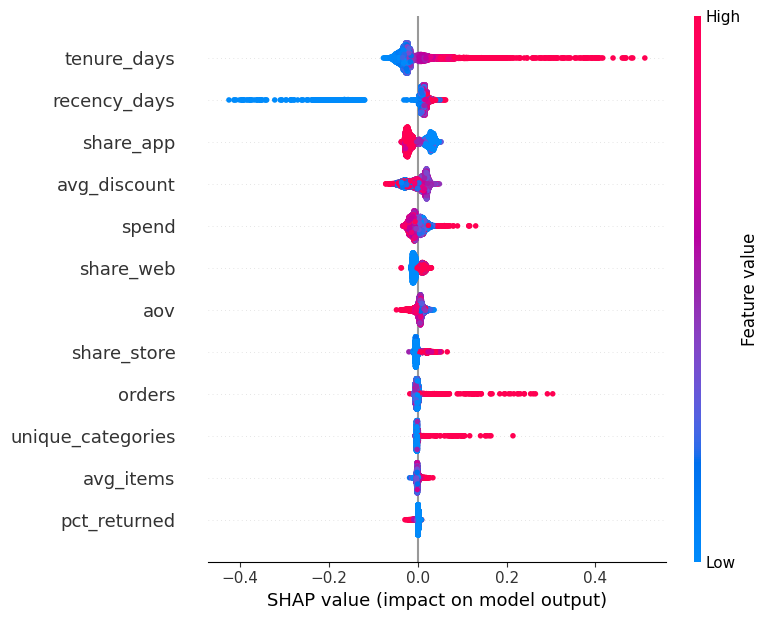

In [25]:
from sklearn.ensemble import RandomForestClassifier
import shap

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:,1]
print("RF ROC-AUC:", roc_auc_score(y_test, proba_rf))
print("RF PR-AUC :", average_precision_score(y_test, proba_rf))

explainer = shap.TreeExplainer(rf)
sv = explainer(X_test)

# If sv.values is 3D: (n_samples, n_features, 2), take class=1
if sv.values.ndim == 3:
    sv_pos = shap.Explanation(
        values=sv.values[:, :, 1],
        base_values=sv.base_values[:, 1] if sv.base_values.ndim > 1 else sv.base_values,
        data=sv.data,
        feature_names=sv.feature_names
    )
    shap.summary_plot(sv_pos, X_test)
else:
    shap.summary_plot(sv, X_test)


In [27]:
sample = (
    tmp.groupby("segment_month", group_keys=False)
       .apply(lambda x: x.sample(n=min(400, len(x)), random_state=42))
       .reset_index(drop=True)
)


/tmp/ipython-input-4194473643.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(400, len(x)), random_state=42))


In [28]:
Xs = sample[m_num_cols].copy()
Xs["spend"] = np.log1p(Xs["spend"])
Xs["aov"]   = np.log1p(Xs["aov"])


In [29]:
import shap

explainer = shap.TreeExplainer(rf)
sv_exp = explainer(Xs)   # Explanation object aligned with Xs

# Convert to a 2D matrix for the positive class if needed
sv_vals = sv_exp.values
if sv_vals.ndim == 3:         # (n_samples, n_features, n_classes)
    sv_vals = sv_vals[:, :, 1]  # take class 1


In [30]:
seg_shap = []

for seg in sorted(sample["segment_month"].unique()):
    mask = (sample["segment_month"] == seg).to_numpy()  # boolean array length = len(sample)

    mean_abs = np.abs(sv_vals[mask]).mean(axis=0)       # (n_features,)
    top_features = pd.Series(mean_abs, index=Xs.columns).sort_values(ascending=False).head(6)

    seg_shap.append({
        "segment_month": seg,
        "top_churn_drivers": ", ".join(top_features.index.tolist())
    })

seg_shap_df = pd.DataFrame(seg_shap)
seg_shap_df


,segment_month,top_churn_drivers
0,0,"tenure_days, spend, share_app, recency_days, a..."
1,1,"recency_days, tenure_days, spend, aov, orders,..."
2,2,"aov, spend, tenure_days, share_app, recency_da..."
3,3,"tenure_days, spend, aov, recency_days, share_a..."
4,4,"tenure_days, spend, aov, share_app, recency_da..."
5,5,"aov, spend, share_app, tenure_days, recency_da..."
